In [34]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
import analysis_functional as a

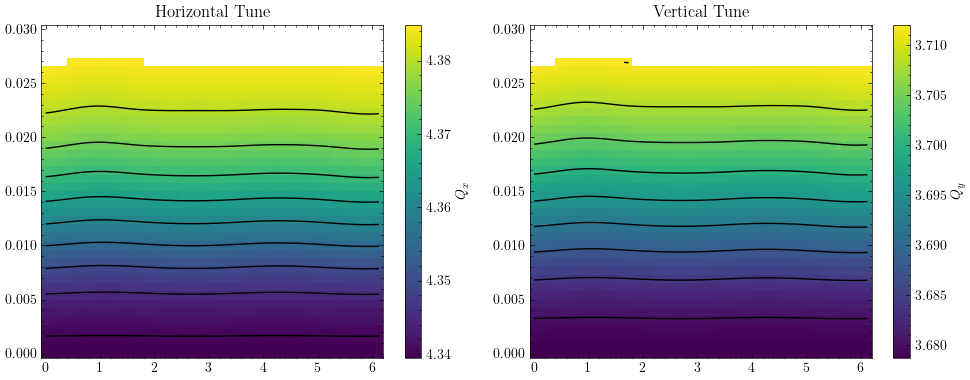

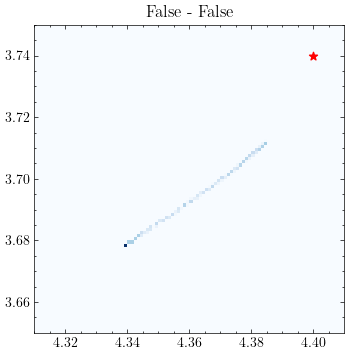

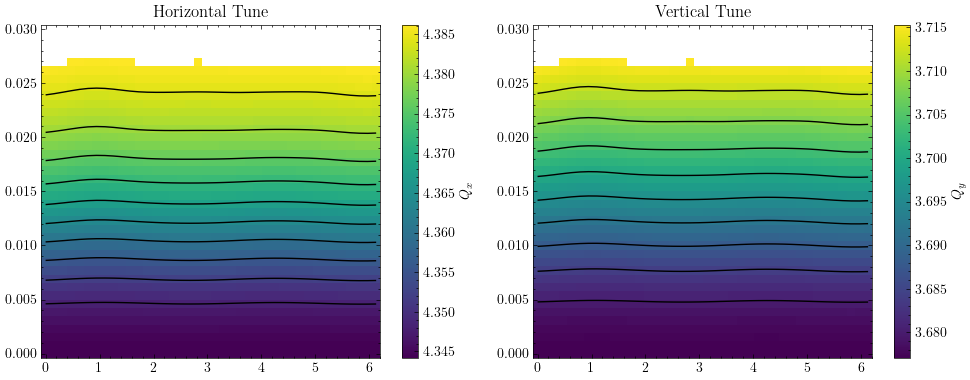

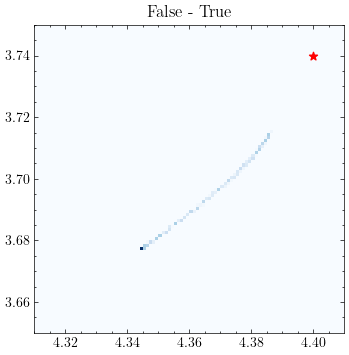

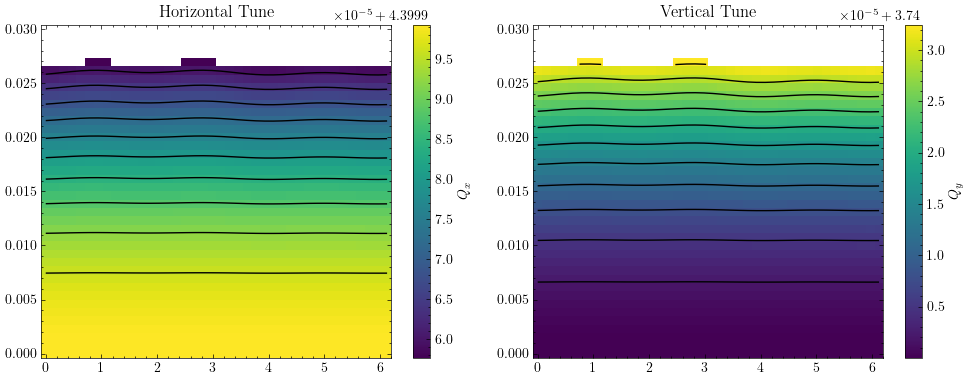

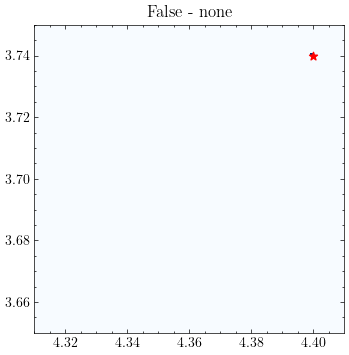

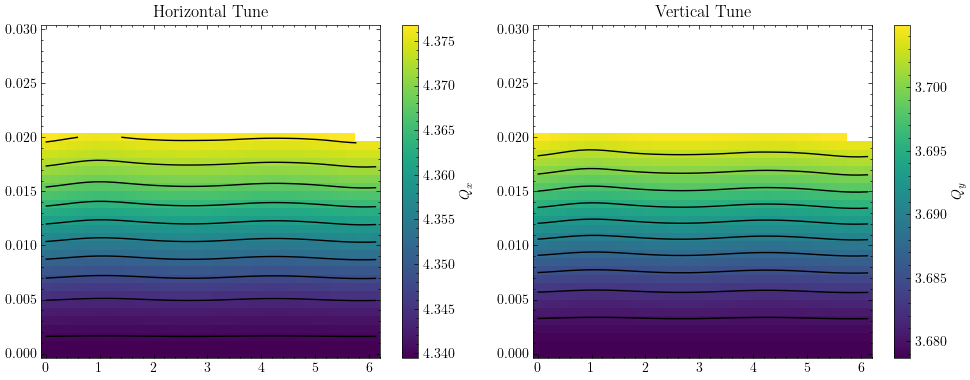

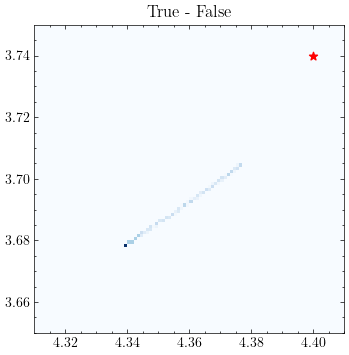

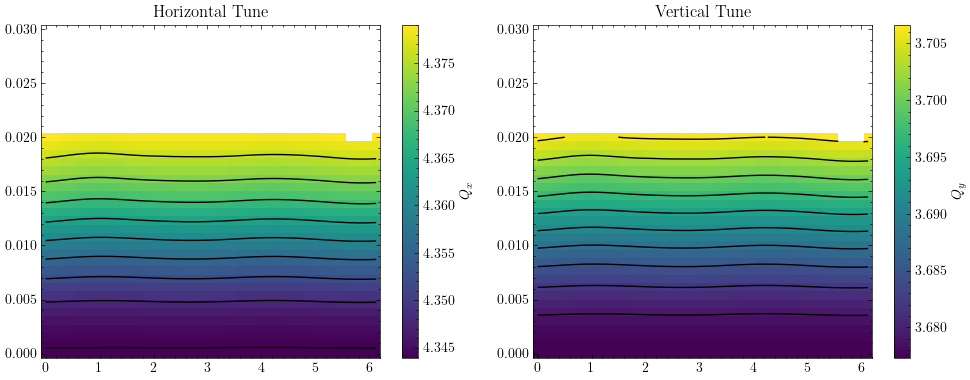

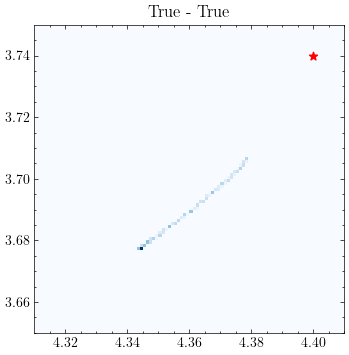

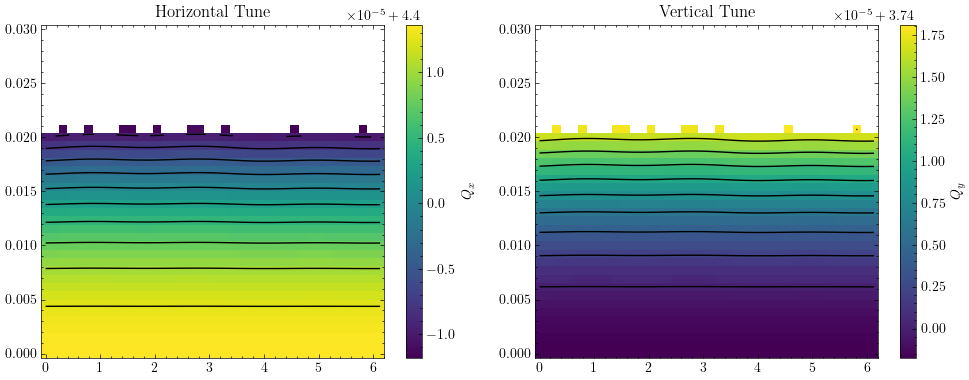

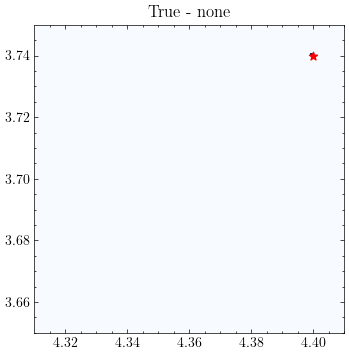

In [35]:
n=40

phase_list = np.linspace(0, 2*np.pi, n, endpoint=False)
sqrt_Jx_list = np.linspace(0, 0.03, n)
sqrt_Jx_grid, phase_grid = np.meshgrid(sqrt_Jx_list, phase_list)

for co_dist in [False, True]:
    for indirect in [False, True, 'none']:
        sim = a.load_simulation(f'data/co_dist:{co_dist}_indirect:{indirect}.h5')
        Qx, Qy = a.get_tunes(sim.x, sim.y, sim.px, sim.py, sim.twiss_df_at_mon, sim.survivor_mask)
        Qx = np.reshape(Qx+4, (n,n))
        Qy = np.reshape(4-Qy, (n,n))

        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
        im0 = axs[0].pcolormesh(phase_grid, sqrt_Jx_grid, Qx, shading='auto')
        axs[0].contour(phase_grid, sqrt_Jx_grid, Qx, levels=10, colors='k')
        fig.colorbar(im0, ax=axs[0], label='$Q_x$')
        axs[0].set_title('Horizontal Tune')
        
        im1 = axs[1].pcolormesh(phase_grid, sqrt_Jx_grid, Qy, shading='auto')
        axs[1].contour(phase_grid, sqrt_Jx_grid, Qy, levels=10, colors='k')
        fig.colorbar(im1, ax=axs[1], label='$Q_y$')
        axs[1].set_title('Vertical Tune')
        
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(4,4))
        ax.hist2d(Qx.flatten(), Qy.flatten(), bins=100, range=[[sim.qx-0.09, sim.qx+0.01],
                                                               [sim.qy-0.09, sim.qy+0.01]], cmap='Blues')
        ax.scatter(sim.qx, sim.qy, c='r', marker='*')
        ax.set_title(f'{co_dist} - {indirect}')
        
        
        